# 1D Variance Preserving (VP) Ornstein-Uhlenbeck Process

## 1. Forward Process
The continuous-time forward diffusion is governed by the constant-temperature VP OU process:
$$dx_t = -\lambda x_t dt + \sqrt{2D} dW_t$$

Where $\lambda = \frac{1}{2}\beta$ and $2D = \beta$. The analytical transition kernel is exact and Gaussian:
$$q(x_t | x_0) = \mathcal{N}\left(x_t; x_0 e^{-\lambda t}, \frac{D}{\lambda}(1 - e^{-2\lambda t})\right)$$

## 2. Bimodal Gaussian Data Distribution & Score
For an initial Gaussian Mixture distribution $p_0(x) = \frac{1}{2}\mathcal{N}(x; \mu_1, \sigma_1^2) + \frac{1}{2}\mathcal{N}(x; \mu_2, \sigma_2^2)$, the marginal at time $t$ remains a Gaussian mixture:
$$p_t(x) = \sum_{i \in \{1,2\}} \frac{1}{2}\mathcal{N}\left(x; \mu_i e^{-\lambda t}, \sigma_i^2 e^{-2\lambda t} + (1 - e^{-2\lambda t})\right)$$

By letting $m_i(t)$ and $S_i(t)$ be the mean and variance of the $i$-th component respectively, the exact analytical score is computed. To guarantee numerical stability against underflows in the Gaussian PDFs, we compute component-wise scores and weigh them via log-space softmax. 

## 3. Denoising Score Matching (DSM)
The neural network $s_\theta(x, t)$ trains conditionally against the analytical perturbation steps. To prevent high variance in stochastic batches (especially for small $t$), we use the standard diffusion scaling weight $\lambda(t) = v_t$:
$$ \mathcal{L}(\theta) = \mathbb{E}_{t, x_0, \epsilon} \left[ v_t \left\| s_\theta(x_t, t) + \frac{\epsilon}{\sqrt{v_t}} \right\|_2^2 \right] $$

Iteration 0500/6000 | Avg DSM Loss: 0.73549
Iteration 1000/6000 | Avg DSM Loss: 0.56190
Iteration 1500/6000 | Avg DSM Loss: 0.55629
Iteration 2000/6000 | Avg DSM Loss: 0.54842
Iteration 2500/6000 | Avg DSM Loss: 0.54667
Iteration 3000/6000 | Avg DSM Loss: 0.54363
Iteration 3500/6000 | Avg DSM Loss: 0.54621
Iteration 4000/6000 | Avg DSM Loss: 0.54406
Iteration 4500/6000 | Avg DSM Loss: 0.54429
Iteration 5000/6000 | Avg DSM Loss: 0.53962
Iteration 5500/6000 | Avg DSM Loss: 0.54035
Iteration 6000/6000 | Avg DSM Loss: 0.54220


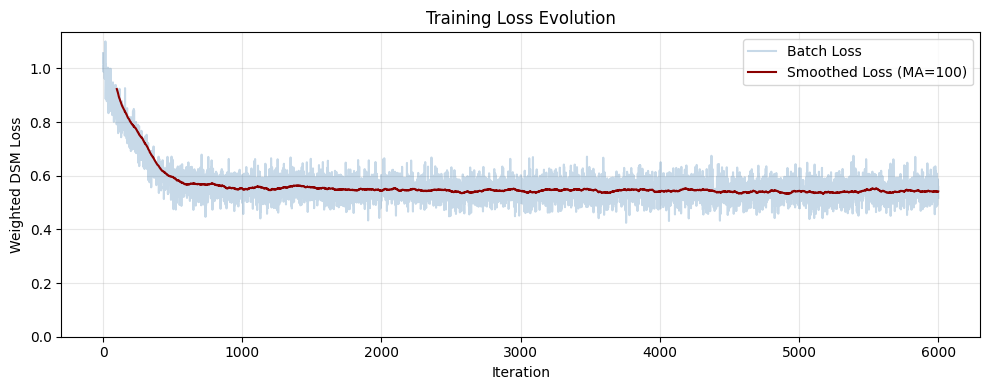

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import math

# Global OU Parameters
beta = 1.0
lam = 0.5 * beta
T = 1.0

# Bimodal Gaussian Parameters
mu_1, sigma_1 = -2.0, 0.5
mu_2, sigma_2 = 2.0, 0.5

# Training Hyperparams
batch_size = 1000
iterations = 6000
lr = 1e-3
t_eps = 1e-4

class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 12), nn.ReLU(),
            nn.Linear(12, 12), nn.ReLU(),
            nn.Linear(12, 1)
        )
    
    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=-1))

def sample_p0(batch_size):
    """Samples x_0 from bimodal Gaussian mixture."""
    modes = torch.randint(0, 2, (batch_size, 1)).float()
    noise = torch.randn(batch_size, 1)
    
    samples_1 = mu_1 + sigma_1 * noise
    samples_2 = mu_2 + sigma_2 * noise
    return (1 - modes) * samples_1 + modes * samples_2

model = ScoreNet()
optimizer = optim.Adam(model.parameters(), lr=lr)

loss_history = []
model.train()

for i in range(iterations):
    optimizer.zero_grad()
    
    x_0 = sample_p0(batch_size)
    t = torch.rand(batch_size, 1) * (T - t_eps) + t_eps
    epsilon = torch.randn_like(x_0)
    
    alpha_t = torch.exp(-lam * t)
    var_t = 1.0 - torch.exp(-beta * t)
    std_t = torch.sqrt(var_t)
    
    x_t = alpha_t * x_0 + std_t * epsilon
    
    score_pred = model(x_t, t)
    score_target = -epsilon / std_t
    
    # Weight the loss by var_t to stabilize training gradients across time
    # This fundamentally minimizes || std_t * score_pred + epsilon ||^2
    loss = torch.mean(var_t * (score_pred - score_target) ** 2)
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if (i + 1) % 500 == 0:
        avg_loss = np.mean(loss_history[-500:])
        print(f"Iteration {i+1:04d}/{iterations} | Avg DSM Loss: {avg_loss:.5f}")

# Plot loss evolution
plt.figure(figsize=(10, 4))
plt.plot(loss_history, alpha=0.3, label="Batch Loss", color="steelblue")

# 100-step moving average
window = 100
smoothed_loss = np.convolve(loss_history, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(loss_history)), smoothed_loss, color="darkred", label=f"Smoothed Loss (MA={window})")

plt.xlabel("Iteration")
plt.ylabel("Weighted DSM Loss")
plt.title("Training Loss Evolution")
plt.ylim(bottom=0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

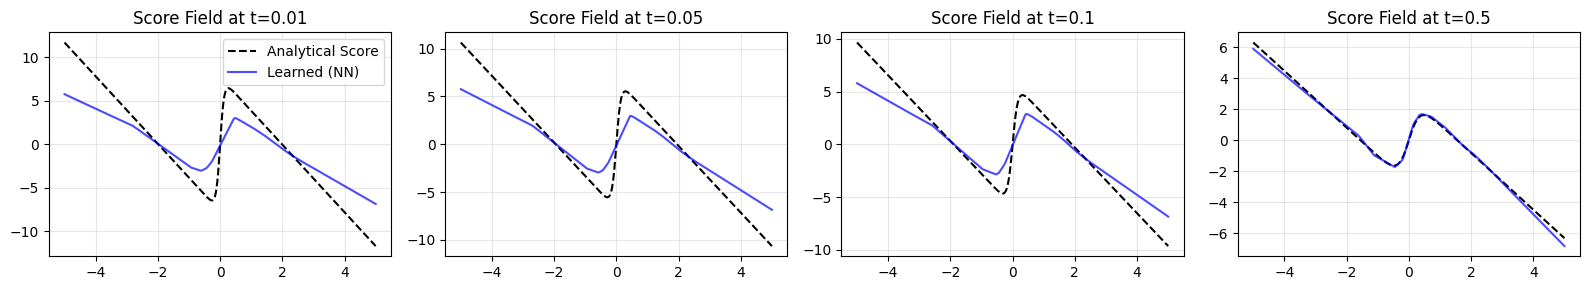

In [23]:
def analytical_score(x, t):
    """
    Computes exact, numerically stable score function for Gaussian Mixture
    using log-sum-exp trick to avoid NaNs caused by pdf underflows.
    """
    alpha_t = torch.exp(-lam * t)
    v_t = 1.0 - torch.exp(-beta * t)
    
    m1_t = alpha_t * mu_1
    S1_t = (alpha_t**2) * (sigma_1**2) + v_t
    
    m2_t = alpha_t * mu_2
    S2_t = (alpha_t**2) * (sigma_2**2) + v_t
    
    # Compute Log PDFs
    log_p1 = -0.5 * math.log(2 * math.pi) - 0.5 * torch.log(S1_t) - 0.5 * ((x - m1_t)**2) / S1_t
    log_p2 = -0.5 * math.log(2 * math.pi) - 0.5 * torch.log(S2_t) - 0.5 * ((x - m2_t)**2) / S2_t
    
    # Stable weighted combination via Softmax
    log_p_stack = torch.stack([log_p1, log_p2], dim=-1)
    weights = torch.softmax(log_p_stack, dim=-1)
    
    w1, w2 = weights[..., 0], weights[..., 1]
    
    # Component scores
    score1 = -(x - m1_t) / S1_t
    score2 = -(x - m2_t) / S2_t
    
    return w1 * score1 + w2 * score2

# Visual Comparison over t
model.eval()
evaluate_times = [0.01, 0.05, 0.1, 0.5]
x_vals = torch.linspace(-5, 5, 400).unsqueeze(1)

fig, axes = plt.subplots(1, len(evaluate_times), figsize=(16, 3))

with torch.no_grad():
    for idx, t_val in enumerate(evaluate_times):
        t_tensor = torch.full_like(x_vals, t_val)
        nn_score = model(x_vals, t_tensor)
        true_score = analytical_score(x_vals, t_tensor)
        
        ax = axes[idx]
        ax.plot(x_vals.numpy(), true_score.numpy(), 'k--', label="Analytical Score")
        ax.plot(x_vals.numpy(), nn_score.numpy(), 'b-', alpha=0.7, label="Learned (NN)")
        ax.set_title(f"Score Field at t={t_val}")
        ax.grid(True, alpha=0.3)
        if idx == 0: ax.legend()

plt.tight_layout()
plt.show()

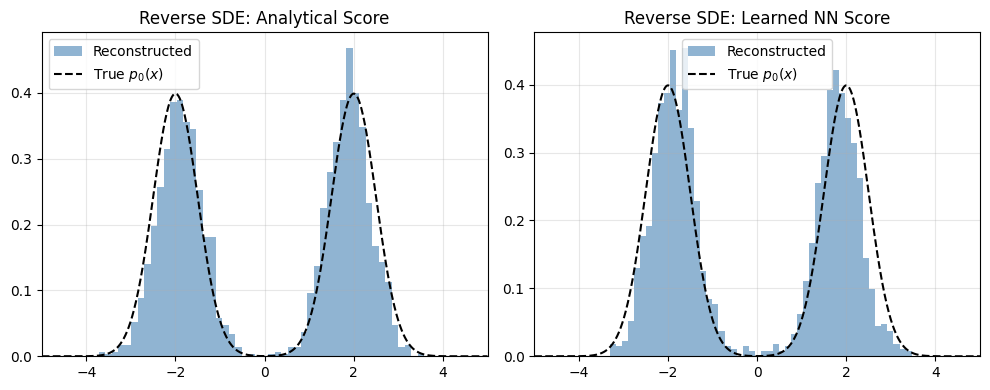

In [15]:
# Reverse-time SDE Anderson Solver
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

def reverse_sampler(score_fn, n_samples=2000, n_steps=500):
    dt = T / n_steps
    # Start at stationary prior N(0,1)
    x = torch.randn(n_samples, 1, device=device) 
    
    for i in range(n_steps):
        t_cur = T - i * dt
        t_tensor = torch.full_like(x, float(t_cur), device=device)
        
        with torch.no_grad():
            score = score_fn(x, t_tensor)
            
        # Reverse SDE: dx = [f(x,t) - g(t)^2 score] dt + g(t) dW
        # where f(x,t) = -lam * x and g(t)^2 = beta
        drift = -lam * x - beta * score
        noise = torch.randn_like(x) if i < n_steps - 1 else torch.zeros_like(x)
        
        x = x - drift * dt + torch.sqrt(torch.tensor(beta * dt, device=device)) * noise
        
    return x.cpu()

# Execute samplers
final_analytical = reverse_sampler(lambda x, t: analytical_score(x.cpu(), t.cpu()).to(device))
final_nn = reverse_sampler(model)

# Plot generated marginal densities against true GMM p0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
x_grid = np.linspace(-5, 5, 800)

p0 = 0.5 * (1/np.sqrt(2*np.pi*sigma_1**2)) * np.exp(-0.5*(x_grid - mu_1)**2 / sigma_1**2) \
   + 0.5 * (1/np.sqrt(2*np.pi*sigma_2**2)) * np.exp(-0.5*(x_grid - mu_2)**2 / sigma_2**2)

for ax, samples, title in zip([ax1, ax2], [final_analytical, final_nn], ["Analytical Score", "Learned NN Score"]):
    ax.hist(samples.numpy(), bins=50, density=True, alpha=0.6, color='steelblue', label='Reconstructed')
    ax.plot(x_grid, p0, 'k--', label='True $p_0(x)$')
    
    ax.set_xlim(-5, 5)
    ax.set_title(f"Reverse SDE: {title}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()